# Tuning but circuit-level

In [1]:
from bbq.field import Field
from bbq.polynomial import Monomial
from bbq.bbq_code import BivariateBicycle
from bbq.circuit import construct_sm_circuit, generate_noisy_circuit, simulate_x_circuit, generate_single_error_circuits, build_hx_dict, build_hz_dict, build_hx_eff, build_hz_eff, construct_decoding_matrix
from bbq.simulation import process_results
from bbq.decoder import RelayBP, BPOSD, BP

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.sparse import coo_matrix, hstack
from relay_bp import RelayDecoderF32


In [15]:
d = 1
field = Field(2)
x, y = Monomial(field, 'x'), Monomial(field, 'y')
a, b = 1 - x, 1 - y

bb = BivariateBicycle(a, b, d, d, 1)
hx, hz = bb.hx, bb.hz
lx, lz = bb.x_logicals, bb.z_logicals
n_qudits = hx.shape[1]

x_order = ['idle', 0, 3, 1, 2]
z_order = [0, 3, 1, 2, 'idle']
num_cycles = d

bp_max_iter = 300
max_iter = 60
first_iter = 80
solutions = 1
relays = 10

circ = construct_sm_circuit(bb, x_order, z_order)


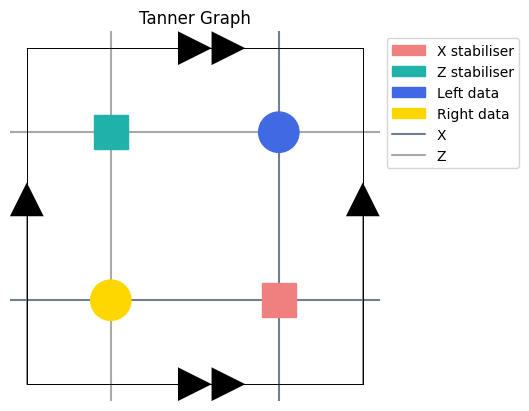

In [ ]:
bb.draw()


In [17]:
# For centre-width plots
centre = np.linspace(0.0, 1, 21)
width = np.linspace(0.0, 2, 21)[1:]

num_trials = 1000
p = 0.003
error_rates = {'Meas': p, 'Prep': p, 'idle': p, 'CNOT': p}
hx_eff, short_hx_eff, hz_eff, short_hz_eff, channel_prob_x, channel_prob_z = construct_decoding_matrix(bb, circ, error_rates, num_cycles)


In [ ]:
short_hx_eff.toarray()


array([[1, 1, 0, 1, 0, 0, 0, 0],
       [1, 1, 0, 1, 0, 0, 0, 1],
       [0, 0, 0, 0, 0, 0, 0, 1]])

In [ ]:
hx_eff.toarray()


array([[1, 1, 0, 1, 0, 0, 0, 0],
       [1, 1, 0, 1, 0, 0, 0, 1],
       [0, 0, 0, 0, 0, 0, 0, 1],
       [0, 1, 0, 0, 1, 1, 0, 0],
       [0, 0, 1, 1, 1, 0, 0, 0]])

In [ ]:
short_hz_eff.toarray()


array([[1, 0, 0, 1, 0, 1, 0],
       [1, 0, 0, 1, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 0]])

In [ ]:
lx


[array([1, 0]), array([0, 1])]

In [ ]:
# For threshold plots
r, s = 0.8, 0.02
physical_error = np.array([s*(r**q) for q in range(10)])
num_failures = [5 for _ in range(10)]

error_rates = {'Meas': s, 'Prep': s, 'idle': s, 'CNOT': s}
hx_eff, short_hx_eff, hz_eff, short_hz_eff, s_channel_prob_x, s_channel_prob_z = construct_decoding_matrix(bb, circ, error_rates, num_cycles)
short_hx_eff = short_hx_eff.toarray()

c = 0.05
w = 0.2


In [ ]:
print(f'Simulation for error rates {physical_error}')

results_rust = []
results_relaybp = []
results_bposd = []
results_bp = []

for ind, p in enumerate(physical_error):
    print(f'Starting trials for p={p:.4f}')

    error_rates = {'Meas': p, 'Prep': p, 'idle': p, 'CNOT': p}

    # Generate prior
    channel_prob_x, channel_prob_z = list(r**ind*np.array(s_channel_prob_x)), list(r**ind*np.array(s_channel_prob_z))
    n_qudits = short_hx_eff.shape[1]
    k = len(lx)
    x_prior = np.zeros((short_hx_eff.shape[1], field.p), dtype=float)
    for i, prob in enumerate(channel_prob_x):
        x_prior[i, 0] = 1 - prob
        for j in range(1, field.p):
            x_prior[i, j] = prob / (field.p - 1)

    failures_rust = 0
    failures_relaybp = 0
    failures_bposd = 0
    failures_bp = 0
    failures = sum([failures_rust, failures_relaybp, failures_bposd, failures_bp])

    trials = 0

    while failures < 4 * num_failures[ind]:
        trials += 1

        mem_weight = np.zeros((n_qudits, field.p, relays))
        mem_weight[:, :, 0] = c
        mem_weight[:, :, 1:] = np.random.uniform(c - w/2, c + w/2, size=(n_qudits, field.p, relays - 1))

        # Generate noisy circ
        noisy_circ, err_cnt = generate_noisy_circuit(bb, circ * num_cycles, error_rates)
        
        # Simulate noisy circ
        x_syndrome_history, x_state, x_syndrome_map, x_err_count = simulate_x_circuit(bb, noisy_circ + circ + circ)

        # Calculate true logical effect
        qudits_dict = bb.qudits_dict
        data_qudits = bb.data_qudits
        x_state_data_qudits = [x_state[qudits_dict[qudit]] for qudit in data_qudits]
        x_syndrome_final_logical = (np.array(lz) @ x_state_data_qudits) % field.p
        
        # Syndrome sparsification
        z_checks = bb.Zchecks
        x_syndrome_history_copy = x_syndrome_history.copy()
        for check in z_checks:
            pos = x_syndrome_map[check]
            assert len(pos) == num_cycles + 2
            for row in range(1, num_cycles + 2):
                x_syndrome_history[pos[row]] -= x_syndrome_history_copy[pos[row-1]]
        x_syndrome_history %= field.p

        # Decode
        if failures_bp < num_failures[ind]:
            bp = BP(field, short_hx_eff, x_prior, bp_max_iter)
            guessed_error, decoder_success, bp_success, posterior = bp.decode(x_syndrome_history, debug=True, metric=False)

            if not np.all((short_hx_eff @ guessed_error) % field.p == x_syndrome_history):
                failures_bp += 1
                if failures_bp == num_failures[ind]:
                    results_bp.append(trials)
                    print(f'Completed BP: {trials}')
                continue

            first_logical_row = bb.l * bb.m * (num_cycles + 2)
            x_syndrome_history_augmented_guessed = (hx_eff @ guessed_error) % field.p
            x_syndrome_final_logical_guessed = x_syndrome_history_augmented_guessed[first_logical_row: first_logical_row + k]
            
            if not np.array_equal(x_syndrome_final_logical_guessed, x_syndrome_final_logical):
                failures_bp += 1

                if failures_bp == num_failures[ind]:
                    results_bp.append(trials)
                    print(f'Completed BP: {trials}')

        if failures_bposd < num_failures[ind]:
            bposd = BPOSD(field, short_hx_eff, x_prior, bp_max_iter)
            guessed_error, decoder_success, bp_success, posterior = bposd.decode(x_syndrome_history, debug=True, metric=False)
            if not np.all((short_hx_eff @ guessed_error) % field.p == x_syndrome_history):
                failures_bposd += 1
                if failures_bposd == num_failures[ind]:
                    results_bposd.append(trials)
                    print(f'Completed BPOSD: {trials}')
                continue

            first_logical_row = bb.l * bb.m * (num_cycles + 2)
            x_syndrome_history_augmented_guessed = (hx_eff @ guessed_error) % field.p
            x_syndrome_final_logical_guessed = x_syndrome_history_augmented_guessed[first_logical_row: first_logical_row + k]
            
            if not np.array_equal(x_syndrome_final_logical_guessed, x_syndrome_final_logical):
                failures_bposd += 1

                if failures_bposd == num_failures[ind]:
                    results_bposd.append(trials)
                    print(f'Completed BPOSD: {trials}')

        if failures_relaybp < num_failures[ind]:
            relaybp = RelayBP(field, short_hx_eff, x_prior, max_iter=max_iter, first_iter=first_iter, solutions=solutions, relays=relays, mem_weight=mem_weight)
            guessed_error, decoder_success, bp_success, posterior = relaybp.decode(x_syndrome_history, debug=True, metric=False)
            if not np.all((short_hx_eff @ guessed_error) % field.p == x_syndrome_history):
                failures_relaybp += 1
                if failures_relaybp == num_failures[ind]:
                    results_relaybp.append(trials)
                    print(f'Completed RelayBP: {trials}')
                continue

            first_logical_row = bb.l * bb.m * (num_cycles + 2)
            x_syndrome_history_augmented_guessed = (hx_eff @ guessed_error) % field.p
            x_syndrome_final_logical_guessed = x_syndrome_history_augmented_guessed[first_logical_row: first_logical_row + k]
            
            if not np.array_equal(x_syndrome_final_logical_guessed, x_syndrome_final_logical):
                failures_relaybp += 1

                if failures_relaybp == num_failures[ind]:
                    results_relaybp.append(trials)
                    print(f'Completed RelayBP: {trials}')

        if failures_rust < num_failures[ind]:
            rustrelaybp = RelayDecoderF32(short_hx_eff, error_priors=np.array(channel_prob_x), gamma0=c, pre_iter=first_iter, num_sets=relays, set_max_iter=max_iter, gamma_dist_interval=(c - w/2, c + w/2), stop_nconv=1)
            x_syndrome_history = x_syndrome_history.astype(np.uint8)
            guessed_error = rustrelaybp.decode(x_syndrome_history)
            if not np.all((short_hx_eff @ guessed_error) % field.p == x_syndrome_history):
                failures_rust += 1
                if failures_rust == num_failures[ind]:
                    results_rust.append(trials)
                    print(f'Completed Rust: {trials}')
                continue

            first_logical_row = bb.l * bb.m * (num_cycles + 2)
            x_syndrome_history_augmented_guessed = (hx_eff @ guessed_error) % field.p
            x_syndrome_final_logical_guessed = x_syndrome_history_augmented_guessed[first_logical_row: first_logical_row + k]
            
            if not np.array_equal(x_syndrome_final_logical_guessed, x_syndrome_final_logical):
                failures_rust += 1

                if failures_rust == num_failures[ind]:
                    results_rust.append(trials)
                    print(f'Completed Rust: {trials}')

        if trials % 20 == 0:
            print(f'UPDATE: {trials} trials reached.')

        failures = sum([failures_rust, failures_relaybp, failures_bposd, failures_bp])
    print(f'[{ind+1}/{len(physical_error)}]')


Simulation for error rates [0.02       0.016      0.0128     0.01024    0.008192   0.0065536
 0.00524288 0.0041943  0.00335544 0.00268435]
Starting trials for p=0.0200
Completed BP: 5
Completed RelayBP: 10
Completed BPOSD: 16
Completed Rust: 16
[1/10]
Starting trials for p=0.0160
Completed BP: 5
Completed BPOSD: 11
Completed RelayBP: 11
Completed Rust: 14
[2/10]
Starting trials for p=0.0128
Completed BP: 5
Completed RelayBP: 14
Completed Rust: 16
UPDATE: 20 trials reached.
Completed BPOSD: 25
[3/10]
Starting trials for p=0.0102
Completed BP: 7
Completed Rust: 16
UPDATE: 20 trials reached.
Completed RelayBP: 25
Completed BPOSD: 27
[4/10]
Starting trials for p=0.0082
Completed BP: 9
UPDATE: 20 trials reached.
Completed Rust: 37
Completed RelayBP: 39
UPDATE: 40 trials reached.
Completed BPOSD: 41
[5/10]
Starting trials for p=0.0066
Completed BP: 13
UPDATE: 20 trials reached.
UPDATE: 40 trials reached.
Completed Rust: 46
UPDATE: 60 trials reached.
UPDATE: 80 trials reached.
Completed Relay

In [ ]:
print(results_rust, results_relaybp, results_bposd, results_bp)


[16, 14, 16, 16, 37, 46, 75, 78, 249, 277] [10, 11, 14, 25, 39, 95, 251, 303, 784, 988] [16, 11, 25, 27, 41, 128, 251, 303, 1279, 988] [5, 5, 5, 7, 9, 13, 16, 10, 37, 81]


In [ ]:
res = {1:np.array(results_rust), 2:np.array(results_relaybp), 3:np.array(results_bposd), 4:np.array(results_bp)}
for i in [1, 2, 3, 4]:
    res[i] += np.array(results_comp5[i])
    res[i] = list(int(d) for d in res[i])


In [ ]:
res


{1: [32, 30, 32, 38, 76, 97, 182, 196, 606, 991],
 2: [20, 22, 28, 47, 63, 160, 439, 667, 1605, 2421],
 3: [29, 32, 39, 52, 80, 201, 523, 659, 2232, 2463],
 4: [10, 10, 10, 15, 15, 23, 33, 21, 85, 197]}

In [ ]:
results_comp5 = {
    1: [32, 30, 32, 38, 76, 97, 182, 196, 606, 991],
    2: [20, 22, 28, 47, 63, 160, 439, 667, 1605, 2421],
    3: [29, 32, 39, 52, 80, 201, 523, 659, 2232, 2463],
    4: [10, 10, 10, 15, 15, 23, 33, 21, 85, 197]
}


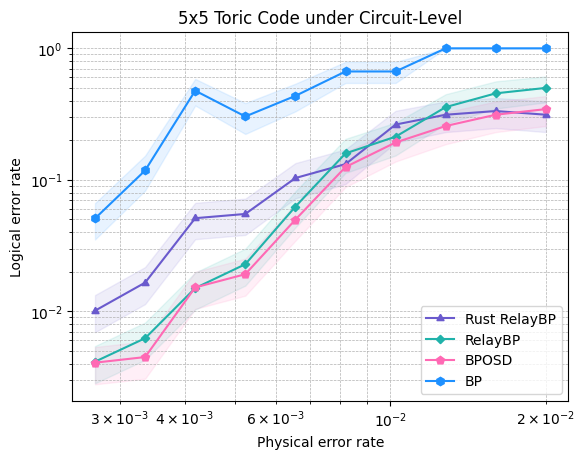

In [ ]:
legend_elements = [
    Line2D([0], [0], color='slateblue', marker=(3, 0, 0), linestyle='-', label='Rust RelayBP'),
    Line2D([0], [0], color='lightseagreen', marker=(4, 0, 0), linestyle='-', label='RelayBP'),
    Line2D([0], [0], color='hotpink', marker=(5, 0, 0), linestyle='-', label='BPOSD'),
    Line2D([0], [0], color='dodgerblue', marker=(6, 0, 0), linestyle='-', label='BP')
]

r, s = 0.8, 0.02
physical_error = np.array([s*(r**q) for q in range(10)])
plot_results, plot_errors = process_results(results_comp5, {1:10, 2:10, 3:10, 4:10}, "code_capacity")
alpha = 0.1

fig, ax = plt.subplots()

ax.loglog(physical_error, plot_results[1], color='slateblue', marker=(3, 0, 0))
ax.loglog(physical_error, plot_results[2], color='lightseagreen', marker=(4, 0, 0))
ax.loglog(physical_error, plot_results[3], color='hotpink', marker=(5, 0, 0))
ax.loglog(physical_error, plot_results[4], color='dodgerblue', marker=(6, 0, 0))
ax.fill_between(physical_error, plot_results[1] - plot_errors[1], plot_results[1] + plot_errors[1], color='slateblue', alpha=alpha)
ax.fill_between(physical_error, plot_results[2] - plot_errors[2], plot_results[2] + plot_errors[2], color='lightseagreen', alpha=alpha)
ax.fill_between(physical_error, plot_results[3] - plot_errors[3], plot_results[3] + plot_errors[3], color='hotpink', alpha=alpha)
ax.fill_between(physical_error, plot_results[4] - plot_errors[4], plot_results[4] + plot_errors[4], color='dodgerblue', alpha=alpha)

ax.set_xlabel('Physical error rate')
ax.set_ylabel('Logical error rate')
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.legend(handles=legend_elements)
ax.set_title('5x5 Toric Code under Circuit-Level');


In [ ]:
results_comp = {
    1: [87, 102, 122, 247, 197, 547, 723, 1075, 1653, 2156],
    2: [68, 82, 112, 253, 197, 588, 751, 1075, 1682, 2150],
    3: [69, 84, 122, 252, 194, 576, 723, 1059, 1653, 2150],
    4: [26, 31, 42, 102, 85, 230, 414, 591, 833, 1375]
}


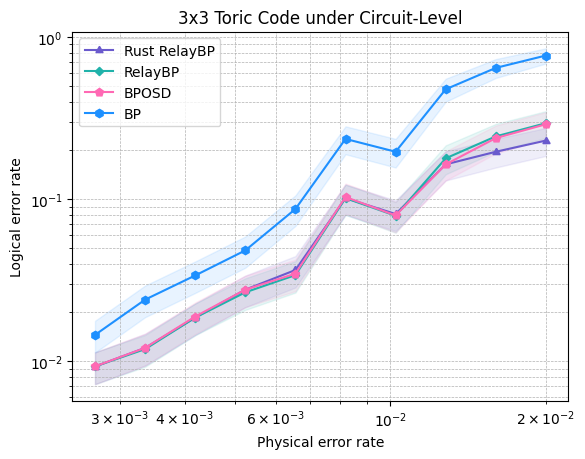

In [ ]:
legend_elements = [
    Line2D([0], [0], color='slateblue', marker=(3, 0, 0), linestyle='-', label='Rust RelayBP'),
    Line2D([0], [0], color='lightseagreen', marker=(4, 0, 0), linestyle='-', label='RelayBP'),
    Line2D([0], [0], color='hotpink', marker=(5, 0, 0), linestyle='-', label='BPOSD'),
    Line2D([0], [0], color='dodgerblue', marker=(6, 0, 0), linestyle='-', label='BP')
]

r, s = 0.8, 0.02
physical_error = np.array([s*(r**q) for q in range(10)])
plot_results, plot_errors = process_results(results_comp, {1:20, 2:20, 3:20, 4:20}, "code_capacity")
alpha = 0.1

fig, ax = plt.subplots()

ax.loglog(physical_error, plot_results[1], color='slateblue', marker=(3, 0, 0))
ax.loglog(physical_error, plot_results[2], color='lightseagreen', marker=(4, 0, 0))
ax.loglog(physical_error, plot_results[3], color='hotpink', marker=(5, 0, 0))
ax.loglog(physical_error, plot_results[4], color='dodgerblue', marker=(6, 0, 0))
ax.fill_between(physical_error, plot_results[1] - plot_errors[1], plot_results[1] + plot_errors[1], color='slateblue', alpha=alpha)
ax.fill_between(physical_error, plot_results[2] - plot_errors[2], plot_results[2] + plot_errors[2], color='lightseagreen', alpha=alpha)
ax.fill_between(physical_error, plot_results[3] - plot_errors[3], plot_results[3] + plot_errors[3], color='hotpink', alpha=alpha)
ax.fill_between(physical_error, plot_results[4] - plot_errors[4], plot_results[4] + plot_errors[4], color='dodgerblue', alpha=alpha)

ax.set_xlabel('Physical error rate')
ax.set_ylabel('Logical error rate')
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.legend(handles=legend_elements)
ax.set_title('3x3 Toric Code under Circuit-Level');


In [ ]:
print(f'Starting full trials over physical error rate {p}')

results = np.zeros((len(centre), len(width)))

for ci, c in enumerate(centre):
    for wi, w in enumerate(width):

        # Generate prior
        x_prior = np.zeros((short_hx_eff.shape[1], field.p), dtype=float)
        for i, prob in enumerate(channel_prob_x):
            x_prior[i, 0] = 1 - prob
            for j in range(1, field.p):
                x_prior[i, j] = prob / (field.p - 1)

        # mem_weight = np.zeros((n_qudits, field.p, relays))
        # mem_weight[:, :, 0] = c
        # mem_weight[:, :, 1:] = np.random.uniform(c - w/2, c + w/2, size=(n_qudits, field.p, relays - 1))

        # mem_weight = np.zeros((n_qudits, field.p, relays))
        # mem_weight[:, :, 0] = c
        # rand = np.random.uniform(c - w/2, c + w/2, size=(n_qudits, relays - 1))
        # for i in range(0, field.p):
        #     mem_weight[:, i, 1:] = rand

        failures = 0

        for t in range(num_trials):
            # Set up decoder
            # relaybp = RelayBP(field, short_hx_eff.toarray(), x_prior, max_iter=max_iter, first_iter=first_iter, solutions=solutions, relays=relays, mem_weight=mem_weight)
            relaybp = RelayDecoderF32(short_hx_eff.toarray(), error_priors=np.array(channel_prob_x), gamma0=c, pre_iter=first_iter, num_sets=relays, set_max_iter=max_iter, gamma_dist_interval=(c - w/2, c + w/2), stop_nconv=1)

            # Generate noisy circ
            noisy_circ, err_cnt = generate_noisy_circuit(bb, circ * num_cycles, error_rates)
            
            # Simulate noisy circ
            x_syndrome_history, x_state, x_syndrome_map, x_err_count = simulate_x_circuit(bb, noisy_circ + circ + circ)

            # Calculate true logical effect
            qudits_dict = bb.qudits_dict
            data_qudits = bb.data_qudits
            x_state_data_qudits = [x_state[qudits_dict[qudit]] for qudit in data_qudits]
            x_syndrome_final_logical = (np.array(lz) @ x_state_data_qudits) % field.p
            
            # Syndrome sparsification
            z_checks = bb.Zchecks
            x_syndrome_history_copy = x_syndrome_history.copy()
            for check in z_checks:
                pos = x_syndrome_map[check]
                assert len(pos) == num_cycles + 2
                for row in range(1, num_cycles + 2):
                    x_syndrome_history[pos[row]] -= x_syndrome_history_copy[pos[row-1]]
            x_syndrome_history %= field.p

            # Decode
            # guessed_error, decoder_success, bp_success, posterior = relaybp.decode(x_syndrome_history, metric=False, debug=True)
            x_syndrome_history = x_syndrome_history.astype(np.uint8)
            guessed_error = relaybp.decode(x_syndrome_history)
            # bposd = BPOSD(field, short_hx_eff.toarray(), x_prior, max_iter=max_iter)
            # guessed_error, _ = bposd.decode(x_syndrome_history)
            # assert np.all((short_hx_eff @ guessed_error) % field.p == x_syndrome_history)

            if not np.all((short_hx_eff @ guessed_error) % field.p == x_syndrome_history):
                failures += 1
                continue
            
            # Check logical effect
            first_logical_row = bb.l * bb.m * (num_cycles + 2)
            k = len(lx)
            x_syndrome_history_augmented_guessed = (hx_eff @ guessed_error) % field.p
            x_syndrome_final_logical_guessed = x_syndrome_history_augmented_guessed[first_logical_row: first_logical_row + k]
            
            if not np.array_equal(x_syndrome_final_logical_guessed, x_syndrome_final_logical):
                failures += 1
        results[ci, wi] = failures
        print(f'Finished {ci+1}/{len(centre)} centres and {wi+1}/{len(width)} widths.')
print('Completed simulation')


Starting full trials over physical error rate 0.003
Finished 1/21 centres and 1/20 widths.
Finished 1/21 centres and 2/20 widths.
Finished 1/21 centres and 3/20 widths.
Finished 1/21 centres and 4/20 widths.
Finished 1/21 centres and 5/20 widths.
Finished 1/21 centres and 6/20 widths.
Finished 1/21 centres and 7/20 widths.
Finished 1/21 centres and 8/20 widths.
Finished 1/21 centres and 9/20 widths.
Finished 1/21 centres and 10/20 widths.
Finished 1/21 centres and 11/20 widths.
Finished 1/21 centres and 12/20 widths.
Finished 1/21 centres and 13/20 widths.
Finished 1/21 centres and 14/20 widths.
Finished 1/21 centres and 15/20 widths.
Finished 1/21 centres and 16/20 widths.
Finished 1/21 centres and 17/20 widths.
Finished 1/21 centres and 18/20 widths.
Finished 1/21 centres and 19/20 widths.
Finished 1/21 centres and 20/20 widths.
Finished 2/21 centres and 1/20 widths.
Finished 2/21 centres and 2/20 widths.
Finished 2/21 centres and 3/20 widths.
Finished 2/21 centres and 4/20 widths.
F

In [ ]:
results


array([[ 98.,  75.,  89.,  81.,  82.,  64.,  81.,  87.,  92., 137., 173.,
        187., 208., 201., 217., 212., 218., 204., 210., 207.],
       [ 27.,  62.,  71.,  67.,  69.,  75.,  78.,  91.,  78.,  75.,  83.,
         70.,  69.,  79.,  82.,  80.,  88.,  72.,  73.,  81.],
       [ 18.,  17.,  20.,  44.,  46.,  42.,  38.,  52.,  55.,  51.,  42.,
         57.,  57.,  45.,  54.,  46.,  42.,  50.,  37.,  49.],
       [ 18.,  13.,  13.,  14.,  28.,  26.,  43.,  29.,  47.,  41.,  32.,
         41.,  36.,  46.,  46.,  39.,  44.,  50.,  50.,  54.],
       [ 13.,   8.,   8.,   9.,  14.,  14.,  27.,  28.,  29.,  36.,  44.,
         33.,  42.,  30.,  39.,  37.,  39.,  31.,  36.,  33.],
       [ 10.,   8.,   5.,   5.,   1.,   7.,  10.,  13.,  18.,  23.,  21.,
         33.,  22.,  25.,  23.,  32.,  25.,  28.,  22.,  26.],
       [ 10.,  13.,   5.,   7.,   8.,   3.,   4.,   6.,  17.,  12.,  22.,
         26.,  25.,  25.,  25.,  31.,  26.,  21.,  37.,  22.],
       [ 10.,  11.,  13.,   8.,   3.,   4

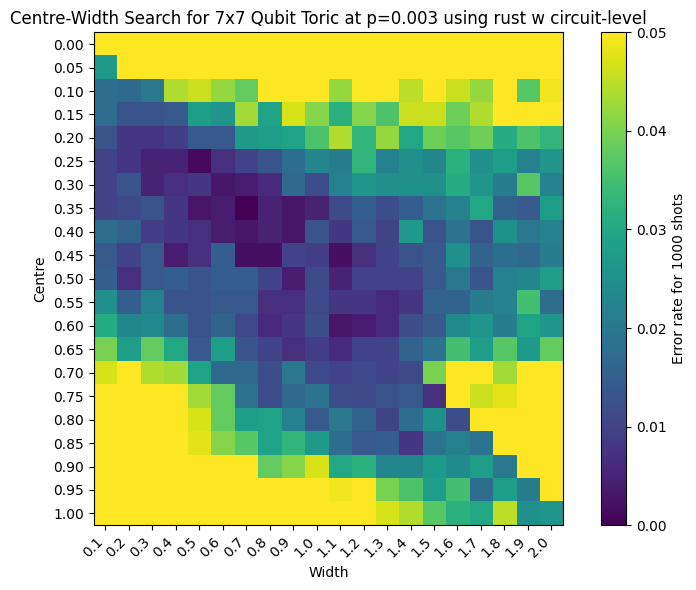

In [ ]:
centre = np.linspace(0.0, 1, 21)
width = np.linspace(0.0, 2, 21)[1:]

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(results / 1000, vmax=0.05)

# Set ticks
ax.set_yticks(np.arange(len(centre)))
ax.set_xticks(np.arange(len(width)))

# Set tick labels
ax.set_yticklabels([f'{c:.2f}' for c in centre])
ax.set_xticklabels([f'{w:.1f}' for w in width])
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Colorbar
plt.colorbar(im, ax=ax, label="Error rate for 1000 shots")

ax.set_title("Centre-Width Search for 7x7 Qubit Toric at p=0.003 using rust w circuit-level")
ax.set_ylabel("Centre")
ax.set_xlabel("Width")

plt.tight_layout()
plt.show()


In [ ]:
results


array([[28., 19., 30., 23., 15., 30., 24., 16., 20., 35., 45., 51., 52.,
        88., 64., 80., 72., 61., 69., 75.],
       [10., 17., 25., 29., 26., 25., 23., 30., 35., 18., 25., 30., 26.,
        26., 27., 20., 31., 31., 34., 23.],
       [ 5.,  3.,  8., 19., 13., 14., 15., 21., 18., 19., 13., 10., 17.,
        27., 24., 18., 24., 13., 25., 14.],
       [ 5.,  7.,  5.,  3.,  4., 13., 11., 10., 18.,  9., 16., 19., 14.,
        17., 13., 17., 23., 16., 22., 15.],
       [ 5.,  4.,  3.,  6.,  2.,  5.,  4.,  8., 15., 10., 14., 12., 15.,
        10., 12., 11., 13., 10., 10., 12.],
       [ 6., 13.,  6.,  6.,  3.,  4.,  4., 10.,  6., 11., 11., 10., 12.,
        10., 10.,  9.,  9., 11., 10., 11.],
       [ 4.,  4.,  4.,  8.,  6.,  8.,  4., 10.,  5.,  7.,  9.,  6.,  7.,
        16., 11.,  5.,  7., 11., 12.,  9.],
       [11.,  5.,  9.,  4.,  3.,  6.,  4.,  3.,  7.,  3.,  5.,  7.,  5.,
         9., 10., 13.,  9.,  7.,  8.,  5.],
       [10.,  5.,  7.,  5.,  3.,  4.,  4.,  5.,  4.,  8.,  8.,  

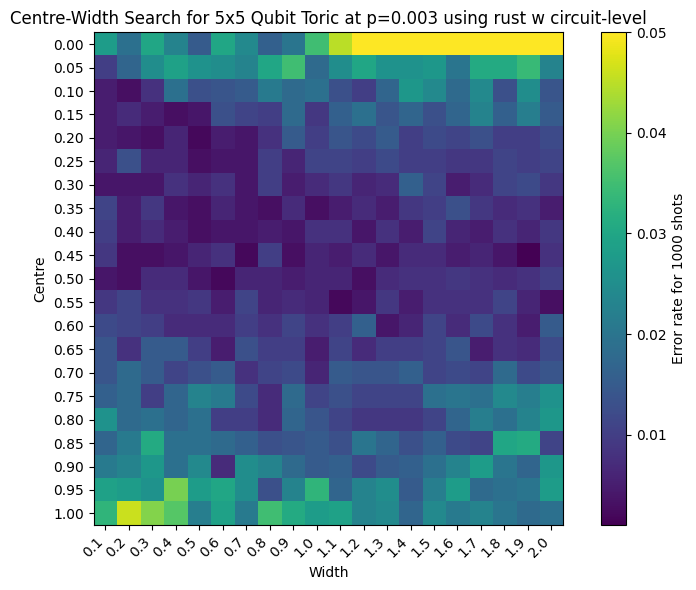

In [ ]:
centre = np.linspace(0.0, 1, 21)
width = np.linspace(0.0, 2, 21)[1:]

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(results / 1000, vmax=0.05)

# Set ticks
ax.set_yticks(np.arange(len(centre)))
ax.set_xticks(np.arange(len(width)))

# Set tick labels
ax.set_yticklabels([f'{c:.2f}' for c in centre])
ax.set_xticklabels([f'{w:.1f}' for w in width])
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Colorbar
plt.colorbar(im, ax=ax, label="Error rate for 1000 shots")

ax.set_title("Centre-Width Search for 5x5 Qubit Toric at p=0.003 using rust w circuit-level")
ax.set_ylabel("Centre")
ax.set_xlabel("Width")

plt.tight_layout()
plt.show()


In [ ]:
results


array([[15., 16., 13., 11., 16., 18., 19., 12., 21., 21., 15., 19., 16.,
        30., 19., 13., 14., 17., 14., 16.],
       [18., 18., 17., 16., 14., 14., 13., 15., 14., 19., 13., 14., 17.,
        12., 15., 13., 10.,  7., 13., 13.],
       [22., 17., 16., 12., 13., 18., 14., 11., 20., 15., 12., 15., 12.,
        11., 14., 11., 11., 15., 18., 14.],
       [17.,  8., 16., 13., 12.,  6., 15., 15., 15.,  8., 11., 17., 16.,
        20., 14., 10., 12., 21., 10.,  8.],
       [16., 12., 12., 20., 14., 12., 10., 17., 12., 11., 10., 11.,  9.,
        13., 14., 16., 11., 14., 20., 15.],
       [11., 19., 13., 16., 15., 18.,  9., 12., 12., 13.,  7., 15., 21.,
         8., 15., 21., 11., 13., 19., 14.],
       [13., 11., 11., 13., 11., 19., 12., 19., 13.,  9.,  6., 11., 19.,
        10., 13., 19., 14., 15., 12., 11.],
       [16., 19., 25., 11., 11., 17., 17., 16., 21.,  5., 12., 15., 22.,
        15.,  9., 21., 20., 14., 12., 12.],
       [18., 14., 19., 13., 14., 15.,  5., 18., 15.,  8., 20.,  

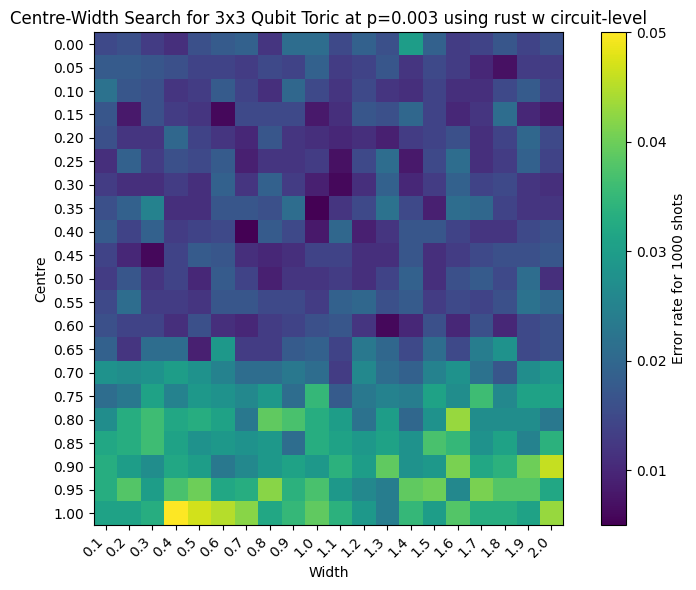

In [ ]:
centre = np.linspace(0.0, 1, 21)
width = np.linspace(0.0, 2, 21)[1:]

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(results / 1000, vmax=0.05)

# Set ticks
ax.set_yticks(np.arange(len(centre)))
ax.set_xticks(np.arange(len(width)))

# Set tick labels
ax.set_yticklabels([f'{c:.2f}' for c in centre])
ax.set_xticklabels([f'{w:.1f}' for w in width])
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Colorbar
plt.colorbar(im, ax=ax, label="Error rate for 1000 shots")

ax.set_title("Centre-Width Search for 3x3 Qubit Toric at p=0.003 using rust w circuit-level")
ax.set_ylabel("Centre")
ax.set_xlabel("Width")

plt.tight_layout()
plt.show()
